## GWO Validation on Four Benchmark Functions (PSO Parameter Mapping)

- Functions: Rastrigin, Styblinski-Tang, Ackley, Griewank
- dim 10: population size 30, iterations 1000
- dim 30: population size 30, iterations 1000
- dim 50: population size 30, iterations 1000

<!-- notebook-role-marker -->
## Notebook Role
This notebook is an ablation study for the group-based leadership mechanism. Alpha remains the best agent, while beta and delta are sampled from ranked leader groups. It is not the final algorithm by itself.

Unified run setting for all result tables: seed rule `BASE_SEED + run`, population size 30, 1000 iterations, 10 independent runs, dimensions 10/30/50, bounds [-5, 5], and the same success criteria for all benchmark functions.

In [7]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [8]:
# PSO -> GWO parameter mapping (keep current PSO scale)
# MAX_VELOCITY -> GWO_RANDOM_STEP (local random perturbation amplitude)
# C1 -> GWO_A0 (initial exploration coefficient a)
# C2 -> GWO_NOISE_SCALE (perturbation scaling)
MAX_VELOCITY = 1.0
BOUNDS = [-5, 5]
C1 = 1
C2 = 1
GWO_RANDOM_STEP = MAX_VELOCITY
GWO_A0 = 2.0 * C1
GWO_NOISE_SCALE = 0.03 * C2

In [9]:
def rastrigin(x: np.ndarray) -> float:
    # A = 10, global minimum at x = 0 with f(x) = 0
    a = 10
    n = len(x)
    return a * n + np.sum(x**2 - a * np.cos(2 * np.pi * x))


def styblinski_tang(x: np.ndarray) -> float:
    # Global minimum at x_i ~= -2.903534 with f(x) ~= -39.16617 * n
    return 0.5 * np.sum(x**4 - 16 * x**2 + 5 * x)


def ackley(x: np.ndarray) -> float:
    # Global minimum at x = 0 with f(x) = 0
    n = len(x)
    term1 = -20.0 * np.exp(-0.2 * np.sqrt(np.sum(x**2) / n))
    term2 = -np.exp(np.sum(np.cos(2 * np.pi * x)) / n)
    return term1 + term2 + 20.0 + np.e


def griewank(x: np.ndarray) -> float:
    # Global minimum at x = 0 with f(x) = 0
    i = np.arange(1, len(x) + 1)
    return np.sum(x**2) / 4000.0 - np.prod(np.cos(x / np.sqrt(i))) + 1.0

In [10]:
class GWO:
    def __init__(self, objective, dim=2, num_particles=30, max_iters=200):
        self.objective = objective
        self.dim = dim
        self.num_particles = num_particles
        self.max_iters = max_iters
        self.leader_group_size = max(1, int(np.ceil(0.1 * num_particles)))

        self.positions = np.random.uniform(BOUNDS[0], BOUNDS[1], (num_particles, dim))
        self.history = []

        self.alpha_pos = None
        self.alpha_score = float("inf")

    def _slice_group(self, start, end, fallback):
        group = self.positions[start:min(end, self.num_particles)]
        return group if len(group) > 0 else fallback

    def _group_representative(self, group):
        rep_idx = np.random.randint(len(group))
        return group[rep_idx].copy()

    def optimize(self):
        for t in range(self.max_iters):
            fitness = np.apply_along_axis(self.objective, 1, self.positions)
            sorted_idx = np.argsort(fitness)
            self.positions = self.positions[sorted_idx]
            fitness = fitness[sorted_idx]

            # alpha fixed as global best particle
            alpha = self.positions[0].copy()

            # beta / delta sampled from their groups
            beta_group = self._slice_group(
                self.leader_group_size, 2 * self.leader_group_size, self.positions[:1]
            )
            delta_group = self._slice_group(
                2 * self.leader_group_size, 3 * self.leader_group_size, beta_group
            )

            beta = self._group_representative(beta_group)
            delta = self._group_representative(delta_group)

            if fitness[0] < self.alpha_score:
                self.alpha_score = float(fitness[0])
                self.alpha_pos = self.positions[0].copy()

            progress = t / max(1, self.max_iters - 1)
            a = GWO_A0 * (1.0 - progress)

            for i in range(self.num_particles):
                r1 = np.random.rand(self.dim)
                r2 = np.random.rand(self.dim)
                A1 = 2.0 * a * r1 - a
                C1v = 2.0 * r2
                D_alpha = np.abs(C1v * alpha - self.positions[i])
                X1 = alpha - A1 * D_alpha

                r1 = np.random.rand(self.dim)
                r2 = np.random.rand(self.dim)
                A2 = 2.0 * a * r1 - a
                C2v = 2.0 * r2
                D_beta = np.abs(C2v * beta - self.positions[i])
                X2 = beta - A2 * D_beta

                r1 = np.random.rand(self.dim)
                r2 = np.random.rand(self.dim)
                A3 = 2.0 * a * r1 - a
                C3v = 2.0 * r2
                D_delta = np.abs(C3v * delta - self.positions[i])
                X3 = delta - A3 * D_delta

                new_pos = (X1 + X2 + X3) / 3.0
                perturb = np.random.uniform(
                    -GWO_RANDOM_STEP, GWO_RANDOM_STEP, self.dim
                ) * GWO_NOISE_SCALE * (1.0 - progress)
                self.positions[i] = np.clip(new_pos + perturb, BOUNDS[0], BOUNDS[1])

            self.history.append(self.alpha_score)

        return self.alpha_pos, self.alpha_score, np.array(self.history)

In [11]:
# Reproducibility
import time

BASE_SEED = 42
NUM_RUNS = 10

dim_list = [10, 30, 50]

# Dimension-wise GWO settings (same scale as original PSO setup)
GWO_SETTINGS = {
    10: {"num_particles": 30, "max_iters": 1000},
    30: {"num_particles": 30, "max_iters": 1000},
    50: {"num_particles": 30, "max_iters": 1000},
}

# Test functions
functions = {
    "Rastrigin": rastrigin,
    "Styblinski-Tang": styblinski_tang,
    "Ackley": ackley,
    "Griewank": griewank,
}

# Success criteria
RAS_TOL_PER_DIM = 1e-2
ST_TOL_PER_DIM = 5e-1
ST_OPTIMUM_PER_DIM = -39.16616570377142
ACKLEY_TOL = 1e-2
GRIEWANK_TOL = 1e-2

def is_success(fname: str, best_value: float, dim: int) -> bool:
    if fname == "Rastrigin":
        return best_value <= (RAS_TOL_PER_DIM * dim)
    if fname == "Styblinski-Tang":
        target = ST_OPTIMUM_PER_DIM * dim
        return abs(best_value - target) <= (ST_TOL_PER_DIM * dim)
    if fname == "Ackley":
        return best_value <= ACKLEY_TOL
    if fname == "Griewank":
        return best_value <= GRIEWANK_TOL
    return False

results = {fname: {} for fname in functions}

for d in dim_list:
    num_particles = GWO_SETTINGS[d]["num_particles"]
    max_iters = GWO_SETTINGS[d]["max_iters"]

    for fname, fobj in functions.items():
        run_best = []
        run_hist = []
        run_time = []

        for run in range(NUM_RUNS):
            seed = BASE_SEED + run
            random.seed(seed)
            np.random.seed(seed)

            t0 = time.perf_counter()
            gwo = GWO(fobj, dim=d, num_particles=num_particles, max_iters=max_iters)
            best_x, best_f, hist = gwo.optimize()
            t1 = time.perf_counter()

            run_best.append(best_f)
            run_hist.append(hist)
            run_time.append(t1 - t0)

        run_best = np.array(run_best)
        run_hist = np.array(run_hist)
        run_time = np.array(run_time)

        success = np.array([is_success(fname, v, d) for v in run_best])

        results[fname][d] = {
            "best": float(np.min(run_best)),
            "mean": float(np.mean(run_best)),
            "std": float(np.std(run_best)),
            "worst": float(np.max(run_best)),
            "success_rate": float(np.mean(success) * 100.0),
            "time_mean_sec": float(np.mean(run_time)),
            "history": np.mean(run_hist, axis=0),
        }

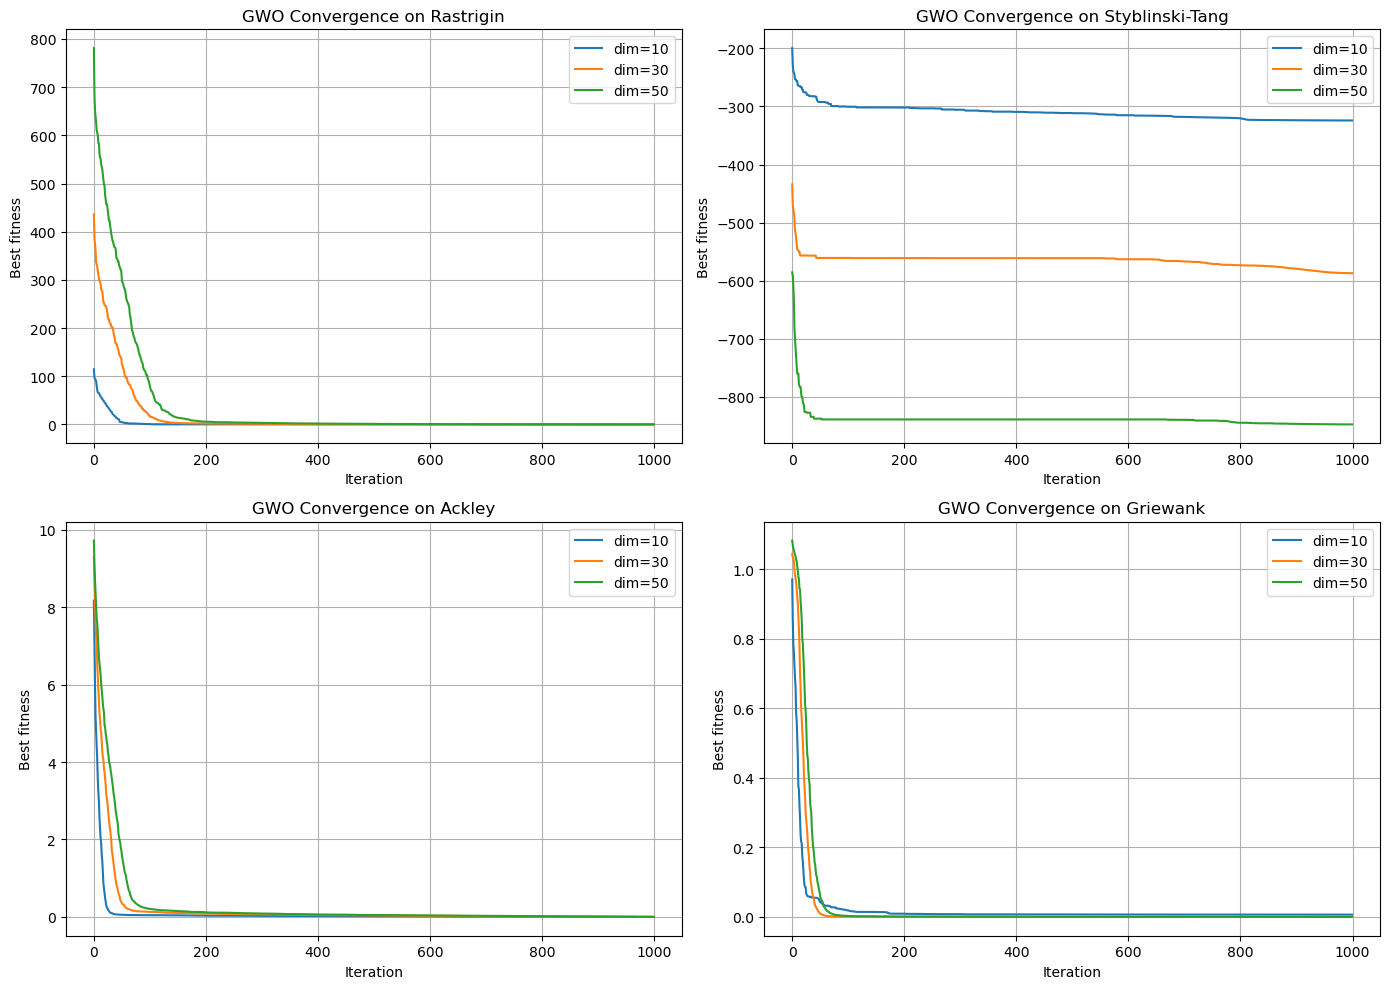

=== Rastrigin (10 runs) ===
dim	best		mean		std		worst		success_rate(%)	mean_time(s)
10	0.000000	0.000001	0.000000	0.000002	100.0		0.8716
30	0.000054	0.000097	0.000032	0.000158	100.0		0.8885
50	0.000317	0.000540	0.000140	0.000762	100.0		1.0369

=== Styblinski-Tang (10 runs) ===
dim	best		mean		std		worst		success_rate(%)	mean_time(s)
10	-352.328239	-324.111411	15.931196	-299.306017	0.0		0.9093
30	-623.985066	-587.257687	35.403424	-520.163821	0.0		0.9290
50	-908.881365	-847.777606	37.045285	-791.055735	0.0		1.1234

=== Ackley (10 runs) ===
dim	best		mean		std		worst		success_rate(%)	mean_time(s)
10	0.000069	0.000097	0.000021	0.000140	100.0		0.9558
30	0.000275	0.000440	0.000095	0.000581	100.0		0.9726
50	0.000664	0.000931	0.000124	0.001094	100.0		1.1308

=== Griewank (10 runs) ===
dim	best		mean		std		worst		success_rate(%)	mean_time(s)
10	0.000000	0.006611	0.012077	0.041062	90.0		0.9226
30	0.000000	0.000000	0.000000	0.000000	100.0		0.9222
50	0.000000	0.000000	0.000000	0.000001	100.0		1.0

In [12]:
# Plot results for all four functions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, fname in enumerate(functions.keys()):
    ax = axes[idx]
    for d in dim_list:
        ax.plot(results[fname][d]["history"], label=f"dim={d}")
    ax.set_title(f"GWO Convergence on {fname}")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Best fitness")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

for fname in functions.keys():
    print(f"=== {fname} ({NUM_RUNS} runs) ===")
    print("dim\tbest\t\tmean\t\tstd\t\tworst\t\tsuccess_rate(%)\tmean_time(s)")
    for d in dim_list:
        s = results[fname][d]
        print(f"{d}\t{s['best']:.6f}\t{s['mean']:.6f}\t{s['std']:.6f}\t{s['worst']:.6f}\t{s['success_rate']:.1f}\t\t{s['time_mean_sec']:.4f}")
    print()